# Dataset Construction and Augmentation

Converts filtered ASNR graphs into PyTorch Geometric Data objects,
performs a stratified train/val/test split, and augments the training set.



In [1]:
from pathlib import Path
import networkx as nx
import pandas as pd
import numpy as np

FOLDER = Path('./asnr datasets')
assert FOLDER.exists(), f"Dataset folder not found: {FOLDER}"

asnr_graphs: dict[str, nx.Graph] = {}
for fp in FOLDER.glob('*.graphml'):
    asnr_graphs[fp.stem + '.graphml'] = nx.read_graphml(fp)

info_frame = pd.read_csv(FOLDER / 'Network_summary_masterfile.csv')

selected_classes = ['Mammalia', 'Insecta', 'Aves']
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]

filtered_df = (
    info_frame[
        info_frame['interaction_type'].isin(selected_interactions) &
        info_frame['class'].isin(selected_classes) &
        (info_frame['nodes'] > 5) &
        pd.notna(info_frame['avg.edge.strength'])
    ]
    .copy()
    .rename(columns={'class': 'network_class'})
    .reset_index(drop=True)
)

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
bio_class_mapping   = {c: i for i, c in enumerate(selected_classes)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

bio_inv         = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}
bio_names       = [bio_inv[i] for i in sorted(bio_inv)]

print(f"Loaded {len(asnr_graphs)} graphs | Filtered: {len(filtered_df)}")


Loaded 1197 graphs | Filtered: 924


In [2]:
import copy, random, torch
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data

def build_dataset(graphs_dict, df_subset):
    dataset = []
    for _, row in df_subset.iterrows():
        key = row['Network_ID']
        if key not in graphs_dict:
            continue
        G = graphs_dict[key]
        G = G.to_undirected() if G.is_directed() else G
        node_mapping = {node: i for i, node in enumerate(G.nodes())}
        clustering   = nx.clustering(G)
        x = torch.tensor(
            [[G.degree(n), clustering[n]] for n in G.nodes()], dtype=torch.float)
        edges = []
        for u, v in G.edges():
            edges += [[node_mapping[u], node_mapping[v]],
                      [node_mapping[v], node_mapping[u]]]
        if not edges:
            continue
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        data            = Data(x=x, edge_index=edge_index,
                               y=torch.tensor([row['interaction_map']], dtype=torch.long))
        data.bio_class  = torch.tensor(
            [bio_class_mapping.get(row['network_class'], -1)], dtype=torch.long)
        data.network_id = key
        dataset.append(data)
    return dataset

def augment_node_drop(data, drop_prob=0.05):
    data_aug  = copy.deepcopy(data)
    num_nodes = data_aug.num_nodes
    if num_nodes <= 5:
        return None
    keep_mask = torch.tensor(
        [random.random() > drop_prob for _ in range(num_nodes)], dtype=torch.bool)
    if keep_mask.sum() < 5:
        return None
    data_aug.x = data_aug.x[keep_mask]
    ei        = data_aug.edge_index
    edge_mask = keep_mask[ei[0]] & keep_mask[ei[1]]
    ei        = ei[:, edge_mask]
    old_to_new = torch.full((num_nodes,), -1, dtype=torch.long)
    old_to_new[keep_mask] = torch.arange(keep_mask.sum())
    data_aug.edge_index = old_to_new[ei]
    return data_aug

def oversample_minority(dataset, df, target_col='interaction_map',
                        copies_per_graph=20, drop_prob=0.08, seed=124):
    random.seed(seed); torch.manual_seed(seed)
    counts         = df[target_col].value_counts()
    majority_count = counts.max()
    augmented      = list(dataset)
    for data in dataset:
        label = data.y.item()
        if counts[label] < majority_count * 5:
            for _ in range(copies_per_graph):
                aug = augment_node_drop(data, drop_prob=drop_prob)
                if aug is not None:
                    augmented.append(aug)
                    counts[label] += 1
    return augmented

train_val_df, test_df = train_test_split(
    filtered_df, test_size=0.15,
    stratify=filtered_df['interaction_map'], random_state=42)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15/0.85,
    stratify=train_val_df['interaction_map'], random_state=42)

train_dataset   = build_dataset(asnr_graphs, train_df)
val_dataset     = build_dataset(asnr_graphs, val_df)
test_dataset    = build_dataset(asnr_graphs, test_df)
augmented_train = oversample_minority(train_dataset, train_df)

print(f"Train: {len(train_dataset)} ({len(augmented_train)} augmented) "
      f"| Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 646 (5507 augmented) | Val: 139 | Test: 139


## Augmented training set distribution

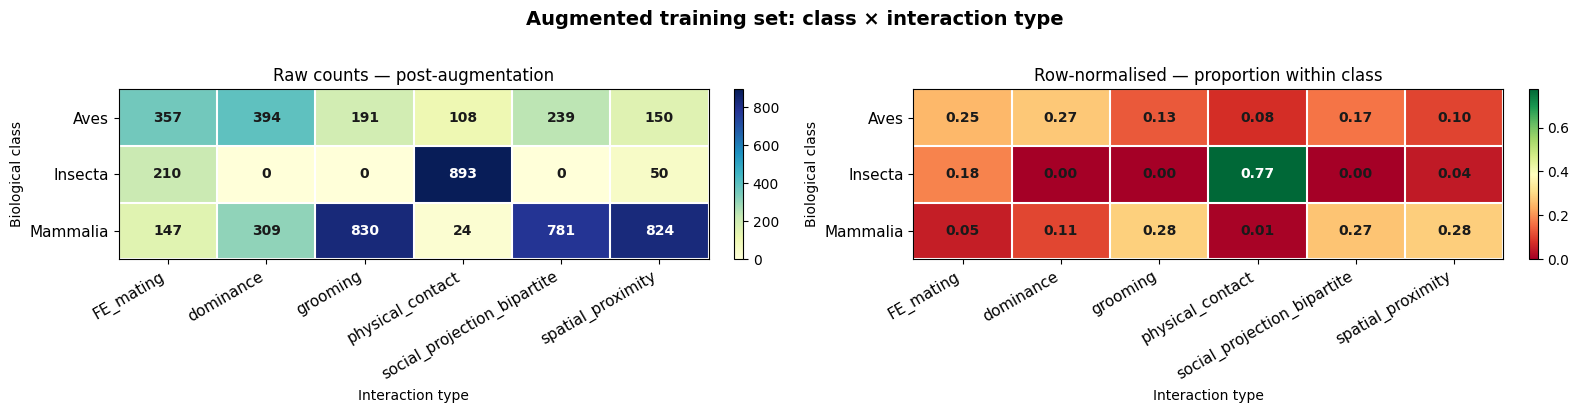

In [3]:
import matplotlib.pyplot as plt

rows = [{'bio_class': bio_inv[s['bio_class'].item()],
         'interaction_type': interaction_inv[s['y'].item()]}
        for s in augmented_train]
df_aug  = pd.DataFrame(rows)
cross   = pd.crosstab(df_aug['bio_class'], df_aug['interaction_type'])
cross_n = cross.div(cross.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, data, fmt, title, cmap in zip(
    axes, [cross, cross_n], ['d', '.2f'],
    ['Raw counts — post-augmentation',
     'Row-normalised — proportion within class'],
    ['YlGnBu', 'RdYlGn'],
):
    im = ax.imshow(data.values, cmap=cmap, aspect='auto', vmin=0, vmax=data.values.max())
    ax.set_xticks(range(len(data.columns))); ax.set_yticks(range(len(data.index)))
    ax.set_xticklabels(data.columns, rotation=30, ha='right', fontsize=11)
    ax.set_yticklabels(data.index, fontsize=11)
    ax.set_xlabel('Interaction type'); ax.set_ylabel('Biological class')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(np.arange(-0.5, len(data.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(data.index),   1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    vmax = data.values.max()
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            v = data.values[i, j]
            ax.text(j, i, format(v, fmt), ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if v > 0.55 * vmax else '#1a1a1a')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Augmented training set: class × interaction type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('augmented_distribution.pdf', bbox_inches='tight')
plt.show()
